In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("stock_1_train.csv")

In [3]:
df.head(2)

,col_0,col_1,col_2,col_3,col_4,target
0,1.574674,0.170111,-0.045997,0.758763,0.185289,223.453581
1,-0.802095,-0.246373,1.640907,-0.141742,-0.163337,211.253687


In [4]:
df.tail(2)

,col_0,col_1,col_2,col_3,col_4,target
19997,-0.443370,1.096142,-0.722360,-0.594727,0.010247,297.370878
19998,2.526569,0.297506,-1.783894,-0.360988,-1.255813,250.789915


In [5]:
df.isnull().any()

col_0     False
col_1     False
col_2     False
col_3     False
col_4     False
target    False
dtype: bool

In [6]:
df.dtypes

col_0     float64
col_1     float64
col_2     float64
col_3     float64
col_4     float64
target    float64
dtype: object

In [7]:
df.describe()

,col_0,col_1,col_2,col_3,col_4,target
count,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000
mean,-0.013095,-0.003817,-0.003564,0.000648,-0.001319,246.140628
std,1.005219,1.005123,0.988177,1.007306,1.012636,39.051280
min,-3.888142,-3.823946,-4.389115,-3.700092,-4.257009,80.000000
25%,-0.684851,-0.682395,-0.668541,-0.673006,-0.683812,219.837480
50%,-0.017108,-0.014430,-0.003593,-0.003000,-0.009435,246.110984
75%,0.660370,0.673075,0.662523,0.670937,0.679278,272.190320
max,5.007235,4.087923,4.326921,4.506746,4.151241,400.000000


Features seem to be normally distributed with mean 0 and standard deviation 1

In [8]:
df.corr()['target']

col_0    -0.385041
col_1     0.646885
col_2    -0.642064
col_3    -0.002781
col_4     0.000560
target    1.000000
Name: target, dtype: float64

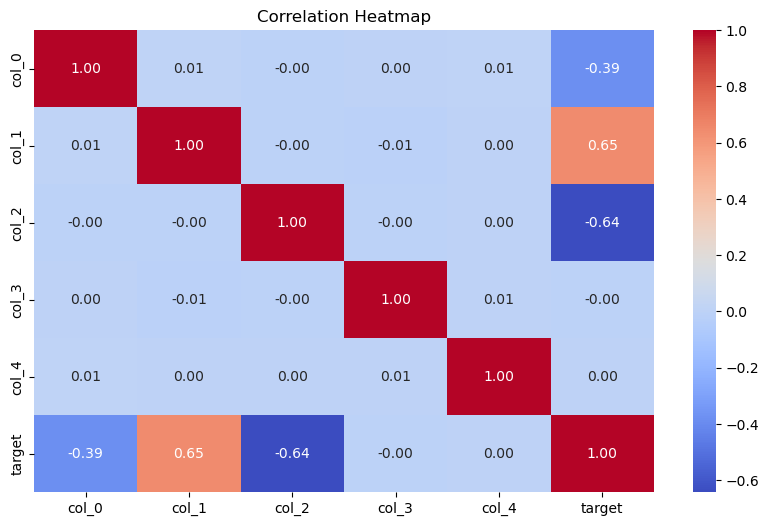

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df['col_0_cut'] = pd.qcut(df['col_0'], 8)

df.groupby(["col_0_cut"], as_index=False, observed=True)['target'].mean()

,col_0_cut,target
0,"(-3.889, -1.179]",270.930324
1,"(-1.179, -0.685]",259.528586
2,"(-0.685, -0.326]",253.807527
3,"(-0.326, -0.0171]",247.704563
4,"(-0.0171, 0.296]",243.658302
5,"(0.296, 0.66]",239.038320
6,"(0.66, 1.148]",233.175621
7,"(1.148, 5.007]",221.280789


C:\Users\kiera\AppData\Local\Temp\ipykernel_16144\3814985213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_0_cut', y='target', palette='viridis')


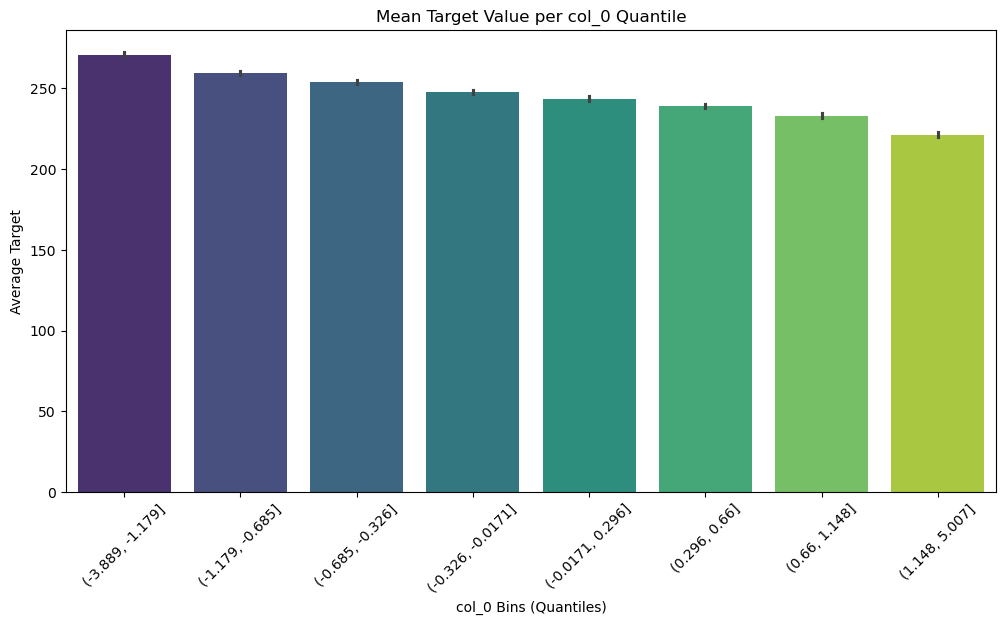

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_0_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_0 Quantile')
plt.xlabel('col_0 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

C:\Users\kiera\AppData\Local\Temp\ipykernel_16144\816166857.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_1_cut', y='target', palette='viridis')


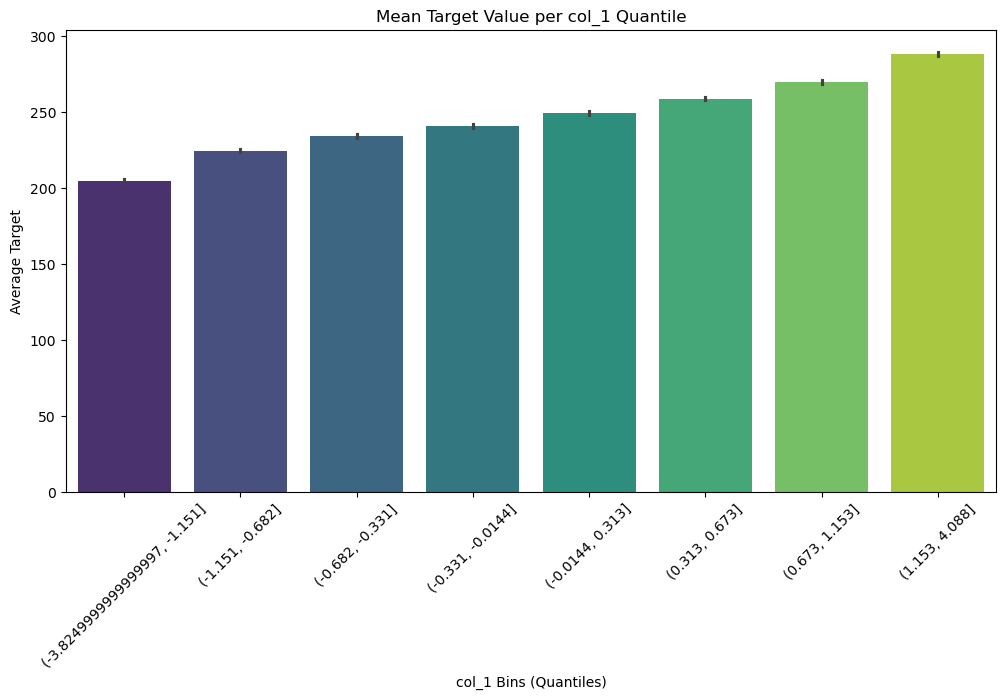

In [12]:
df['col_1_cut'] = pd.qcut(df['col_1'], 8)

df.groupby(["col_1_cut"], as_index=False, observed=True)['target'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_1_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_1 Quantile')
plt.xlabel('col_1 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

C:\Users\kiera\AppData\Local\Temp\ipykernel_16144\2371019045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_2_cut', y='target', palette='viridis')


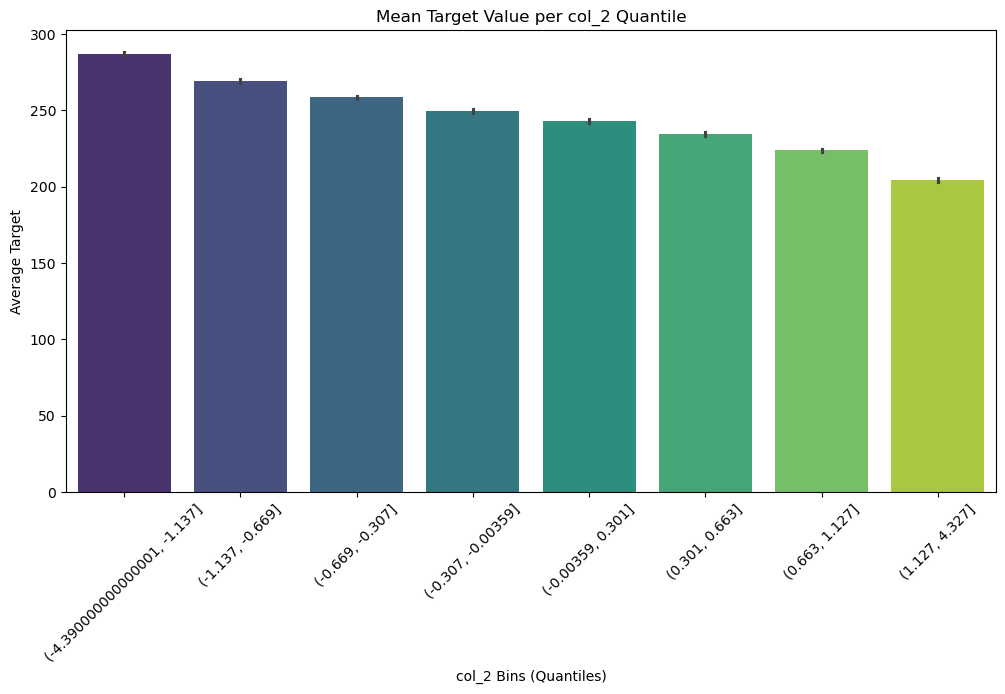

In [13]:
df['col_2_cut'] = pd.qcut(df['col_2'], 8)

df.groupby(["col_2_cut"], as_index=False, observed=True)['target'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_2_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_2 Quantile')
plt.xlabel('col_2 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [14]:
df["col_0_col_1_difference"] = df["col_0"] - df["col_1"]
df["col_1_col_2_difference"] = df["col_1"] - df["col_2"]

In [15]:
correlations = df.corr(numeric_only=True)['target']
print(correlations)

col_0                    -0.385041
col_1                     0.646885
col_2                    -0.642064
col_3                    -0.002781
col_4                     0.000560
target                    1.000000
col_0_col_1_difference   -0.733426
col_1_col_2_difference    0.910477
Name: target, dtype: float64


In [16]:
df["col_0_col_1_difference_div"] = df["col_0"] / df["col_1"]
df["col_1_col_2_difference_div"] = df["col_1"] / df["col_2"]
df["col_0_col_2_difference_div"] = df["col_0"] / df["col_2"]

In [17]:
correlations = df.corr(numeric_only=True)['target']
print(correlations)

col_0                        -0.385041
col_1                         0.646885
col_2                        -0.642064
col_3                        -0.002781
col_4                         0.000560
target                        1.000000
col_0_col_1_difference       -0.733426
col_1_col_2_difference        0.910477
col_0_col_1_difference_div   -0.007746
col_1_col_2_difference_div    0.008786
col_0_col_2_difference_div   -0.002599
Name: target, dtype: float64


In [18]:
X = df[['col_1_col_2_difference']]
y = df['target']
model = LinearRegression().fit(X, y)

df['leftover'] = y - model.predict(X)

print(df[['leftover', 'col_0']].corr())

          leftover     col_0
leftover  1.000000 -0.953452
col_0    -0.953452  1.000000


In [19]:
df['diff_1_2'] = df['col_1'] - df['col_2']
X = df[['diff_1_2', 'col_0']]
y = df['target']

model = LinearRegression()
model.fit(X, y)

A = model.coef_[0]
B = model.coef_[1]
intercept = model.intercept_

print(f"Detected Formula: Target = ({A:.2f} * (col_1 - col_2)) + ({B:.2f} * col_0) + {intercept:.2f}")

r2 = model.score(X, y)
print(f"Formula Accuracy (R^2): {r2:.5f}")

Detected Formula: Target = (25.31 * (col_1 - col_2)) + (-15.32 * col_0) + 245.95
Formula Accuracy (R^2): 0.98446


In [20]:
df['prediction'] = (25.31 * (df['col_1'] - df['col_2'])) + (-15.32 * df['col_0']) + 245.95

df['final_error'] = df['target'] - df['prediction']

df['col_0_sq'] = df['col_0']**2
print(df[['final_error', 'col_0_sq', 'col_3', 'col_4']].corr()['final_error'])

final_error    1.000000
col_0_sq       0.002364
col_3          0.002334
col_4          0.014092
Name: final_error, dtype: float64


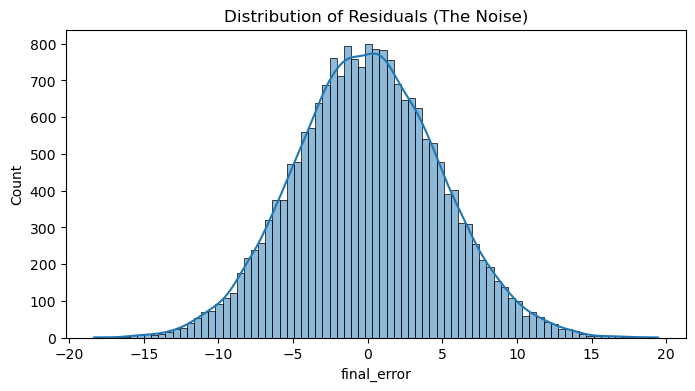

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df['final_error'], kde=True)
plt.title('Distribution of Residuals (The Noise)')
plt.show()

In [22]:
df['col_0_sq'] = df['col_0']**2
df['col_0_cube'] = df['col_0']**3

df['combo_0_1_2'] = df['col_0'] * df['diff_1_2']

df['abs_diff'] = np.abs(df['col_1'] - df['col_2'])

new_candidates = ['col_0_sq', 'col_0_cube', 'combo_0_1_2', 'abs_diff', 'col_3', 'col_4']
corrs = df[new_candidates].corrwith(df['final_error']).abs().sort_values(ascending=False)

print("Correlation with the remaining 1.6% error:")
print(corrs)

Correlation with the remaining 1.6% error:
combo_0_1_2    0.016656
col_4          0.014092
abs_diff       0.011641
col_0_sq       0.002364
col_3          0.002334
col_0_cube     0.000037
dtype: float64


In [23]:
# Test different transformations of col_0 against the leftover
df['col_0_sq'] = df['col_0']**2
df['col_0_sqrt'] = np.sqrt(df['col_0'].clip(lower=0)) # clip to avoid NaNs
df['col_0_abs'] = df['col_0'].abs()

# Check correlations again
test_cols = ['col_0', 'col_0_sq', 'col_0_sqrt', 'col_0_abs']
print(df[test_cols].corrwith(df['leftover']))

col_0        -0.953452
col_0_sq      0.023829
col_0_sqrt   -0.850451
col_0_abs     0.017439
dtype: float64


In [24]:
# 1. Calculate the Standard Deviation of your leftovers (the noise)
noise_std = df['leftover'].std()

# 2. Create your prediction
df['base_prediction'] = (25.31 * (df['col_1'] - df['col_2'])) + (-15.32 * df['col_0']) + 245.95

# 3. Create the 'Confidence Spread' (95% confidence)
df['lower_bound'] = df['base_prediction'] - (2 * noise_std)
df['upper_bound'] = df['base_prediction'] + (2 * noise_std)

print(f"The average 'wiggle room' for the target is +/- {2 * noise_std:.2f}")

The average 'wiggle room' for the target is +/- 32.30


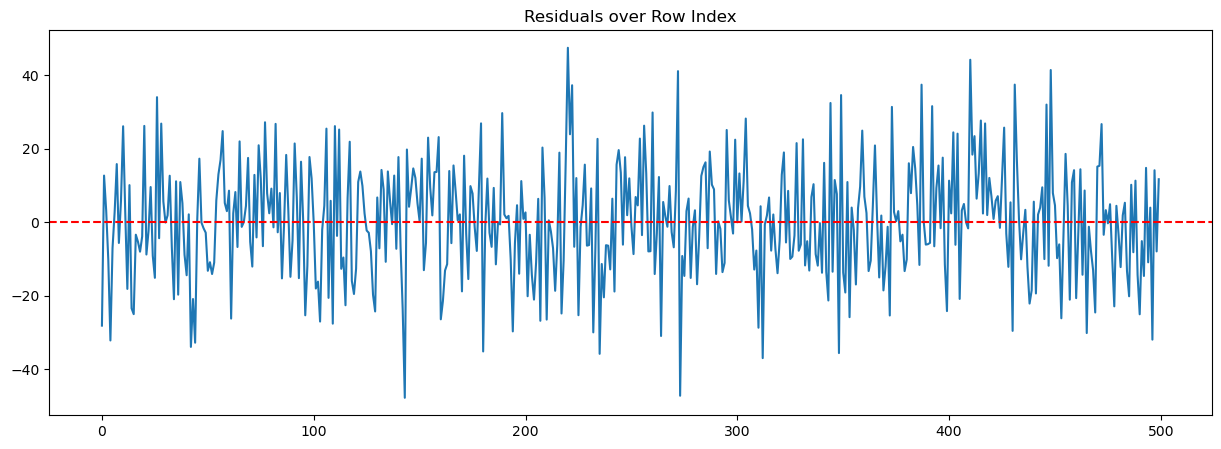

In [25]:
plt.figure(figsize=(15, 5))
plt.plot(df['leftover'].iloc[:500]) # Look at the first 500 rows
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals over Row Index')
plt.show()

In [26]:
# Combine both features
X_combined = df[['col_1_col_2_difference', 'col_0']]
y = df['target']

final_model = LinearRegression().fit(X_combined, y)

print(f"R^2 Score: {final_model.score(X_combined, y)}")

R^2 Score: 0.984464210608838


In [27]:
# Re-calculate residuals for 98.4% model
X_current = df[['col_1_col_2_difference', 'col_0']]
y = df['target']
current_model = LinearRegression().fit(X_current, y)

df['new_leftover'] = y - current_model.predict(X_current)

# Check correlation with the remaining features
print(df[['new_leftover', 'col_3', 'col_4']].corr())

              new_leftover     col_3     col_4
new_leftover      1.000000  0.002334  0.014092
col_3             0.002334  1.000000  0.005163
col_4             0.014092  0.005163  1.000000


In [28]:
X_all = df[['col_0', 'col_1', 'col_2', 'col_3', 'col_4']] # include col_1/2 diff if you prefer
print("Max Possible R^2:", LinearRegression().fit(X_all, y).score(X_all, y))

Max Possible R^2: 0.9844744355512658


In [29]:
# Create interaction and squared terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[['col_0', 'col_1', 'col_2']])

# Fit a simple linear model on these new complex features
poly_model = LinearRegression().fit(X_poly, y)

print(f"Polynomial R^2: {poly_model.score(X_poly, y)}")
print("Feature names:", poly.get_feature_names_out())

Polynomial R^2: 0.9844798646178131
Feature names: ['col_0' 'col_1' 'col_2' 'col_0^2' 'col_0 col_1' 'col_0 col_2' 'col_1^2'
 'col_1 col_2' 'col_2^2']


In [30]:
# Create features based on the tree's discovery
df['is_col_1_high'] = (df['col_1'] > 0.08).astype(int)
df['is_col_2_high'] = (df['col_2'] > 0.08).astype(int)

# Combine your original features with these new "switches"
X_final = df[['col_0', 'col_1', 'col_2', 'is_col_1_high', 'is_col_2_high']]
final_score = LinearRegression().fit(X_final, y).score(X_final, y)

print(f"New Linear R^2: {final_score}")

New Linear R^2: 0.9844728388200451


In [31]:
# Create the "switches" again
df['switch_1'] = (df['col_1'] > 0.08).astype(int)
df['switch_2'] = (df['col_2'] > 0.08).astype(int)

# Create INTERACTION terms (The magic ingredient)
df['col_0_x_switch1'] = df['col_0'] * df['switch_1']
df['col_1_x_switch2'] = df['col_1'] * df['switch_2']

# Use the original columns + the switches + the interactions
X_final = df[['col_0', 'col_1', 'col_2', 'switch_1', 'switch_2', 'col_0_x_switch1', 'col_1_x_switch2']]
model_final = LinearRegression().fit(X_final, y)

print(f"Final Combined R^2: {model_final.score(X_final, y)}")

Final Combined R^2: 0.9844739577987629


In [32]:
# 1. Check for 'Step' data (Integer targets)
unique_count = len(df['target'].unique())
print(f"Unique target values: {unique_count} out of {len(df)} rows")

# 2. Define trial features
trials = {
    "Original": df[['col_0', 'col_1', 'col_2']],
    "Floor": df[['col_0', 'col_1', 'col_2']].apply(np.floor),
    "Round": df[['col_0', 'col_1', 'col_2']].apply(np.round),
    "Abs_Diff": pd.DataFrame({
        'col_0': df['col_0'], 
        'abs_diff': (df['col_1'] - df['col_2']).abs()
    }),
    "ReLU_Diff": pd.DataFrame({
        'col_0': df['col_0'], 
        'relu_diff': (df['col_1'] - df['col_2']).clip(lower=0)
    }),
    "Max_Col": pd.DataFrame({
        'col_0': df['col_0'], 
        'max_1_2': np.maximum(df['col_1'], df['col_2'])
    }),
    "Min_Col": pd.DataFrame({
        'col_0': df['col_0'], 
        'min_1_2': np.minimum(df['col_1'], df['col_2'])
    })
}

# 3. Run the competition
y = df['target']
for name, X_trial in trials.items():
    score = LinearRegression().fit(X_trial, y).score(X_trial, y)
    print(f"{name:10} R^2 Score: {score:.6f}")

Unique target values: 19999 out of 19999 rows
Original   R^2 Score: 0.984471
Floor      R^2 Score: 0.907876
Round      R^2 Score: 0.908538
Abs_Diff   R^2 Score: 0.148263
ReLU_Diff  R^2 Score: 0.761040
Max_Col    R^2 Score: 0.148406
Min_Col    R^2 Score: 0.148351


In [33]:
high_segment = df[df['col_1'] > 0.08]
low_segment = df[df['col_1'] <= 0.08]

model_high = LinearRegression().fit(high_segment[['col_0', 'col_1', 'col_2']], high_segment['target'])
model_low = LinearRegression().fit(low_segment[['col_0', 'col_1', 'col_2']], low_segment['target'])

print(f"High Segment R^2: {model_high.score(high_segment[['col_0', 'col_1', 'col_2']], high_segment['target'])}")
print(f"Low Segment R^2: {model_low.score(low_segment[['col_0', 'col_1', 'col_2']], low_segment['target'])}")

High Segment R^2: 0.9786907711519436
Low Segment R^2: 0.9788607660152402


In [34]:
df['abs_diff'] = np.abs(df['col_1'] - df['col_2'])
X_abs = df[['col_0', 'abs_diff']]
print("Absolute Diff R^2:", LinearRegression().fit(X_abs, y).score(X_abs, y))

Absolute Diff R^2: 0.14826263403310602


In [35]:
# Create a 'Library' of possible transformations
library = {
    'log_col0': np.log(np.abs(df['col_0']) + 1),
    'sq_col1': df['col_1']**2,
    'interaction': df['col_1'] * df['col_2'],
    'sign_col1': np.sign(df['col_1']),
    'sin_col0': np.sin(df['col_0'])
}

for name, feature in library.items():
    corr = np.corrcoef(feature, df['new_leftover'])[0, 1]
    if abs(corr) > 0.5:
        print(f"Strong match found: {name} with correlation {corr}") # no result!

In [36]:
# Let's define the base 'difference' since that was your strongest lead
diff = df['col_1'] - df['col_2']

deep_trials = {
    "Square_Diff": pd.DataFrame({'c0': df['col_0'], 'd2': diff**2}),
    "Cube_Diff":   pd.DataFrame({'c0': df['col_0'], 'd3': diff**3}),
    "Exp_Diff":    pd.DataFrame({'c0': df['col_0'], 'exp': np.exp(np.clip(diff, -10, 10))}),
    "Log_Abs_Diff": pd.DataFrame({'c0': df['col_0'], 'log': np.log(np.abs(diff) + 1e-5)}),
    "Sigmoid_Diff": pd.DataFrame({'c0': df['col_0'], 'sig': 1 / (1 + np.exp(-diff))}),
    "Interaction":  pd.DataFrame({'c0': df['col_0'], 'c1_x_c2': df['col_1'] * df['col_2']}),
    "Ratio":        pd.DataFrame({'c0': df['col_0'], 'ratio': df['col_1'] / (df['col_2'] + 1e-5)})
}

y = df['target']
for name, X_trial in deep_trials.items():
    # We use dropna in case of Log/Ratio issues
    valid = X_trial.replace([np.inf, -np.inf], np.nan).dropna().index
    score = LinearRegression().fit(X_trial.loc[valid], y.loc[valid]).score(X_trial.loc[valid], y.loc[valid])
    print(f"{name:15} R^2 Score: {score:.6f}")

Square_Diff     R^2 Score: 0.148259
Cube_Diff       R^2 Score: 0.660177
Exp_Diff        R^2 Score: 0.463948
Log_Abs_Diff    R^2 Score: 0.148257
Sigmoid_Diff    R^2 Score: 0.955146
Interaction     R^2 Score: 0.148267
Ratio           R^2 Score: 0.148375


In [37]:
df['diff'] = df['col_1'] - df['col_2']

# Create 'Pos_Diff' and 'Neg_Diff'
df['diff_above_zero'] = np.where(df['diff'] > 0, df['diff'], 0)
df['diff_below_zero'] = np.where(df['diff'] <= 0, df['diff'], 0)

X_piecewise = df[['col_0', 'diff_above_zero', 'diff_below_zero']]
y = df['target']

model_piecewise = LinearRegression().fit(X_piecewise, y)
print(f"Piecewise R^2 Score: {model_piecewise.score(X_piecewise, y):.10f}")

Piecewise R^2 Score: 0.9844663162


In [38]:
# 1. Create Sign-based features
df['diff'] = df['col_1'] - df['col_2']
df['sign_1'] = np.sign(df['col_1'])
df['sign_2'] = np.sign(df['col_2'])
df['sign_diff'] = np.sign(df['diff'])

# 2. Test if the 'difference' only matters when it's positive vs negative
# (Interaction between the value and its own sign)
quadrant_trials = {
    "Sign_Flip_0": pd.DataFrame({'c0': df['col_0'], 'feat': df['diff'] * df['sign_1']}),
    "Sign_Flip_1": pd.DataFrame({'c0': df['col_0'], 'feat': df['diff'] * df['sign_2']}),
    "Sign_Flip_2": pd.DataFrame({'c0': df['col_0'], 'feat': df['diff'] * df['sign_diff']}),
    "Absolute_Sum": pd.DataFrame({'c0': df['col_0'], 'feat': np.abs(df['col_1']) + np.abs(df['col_2'])}),
    "XOR_Logic": pd.DataFrame({'c0': df['col_0'], 'c1': df['col_1'], 'c2': df['col_2'], 'xor': (df['sign_1'] * df['sign_2']) * df['diff']})
}

y = df['target']
for name, X_trial in quadrant_trials.items():
    score = LinearRegression().fit(X_trial, y).score(X_trial, y)
    print(f"{name:15} R^2 Score: {score:.10f}")

Sign_Flip_0     R^2 Score: 0.1482571005
Sign_Flip_1     R^2 Score: 0.1482570857
Sign_Flip_2     R^2 Score: 0.1482626340
Absolute_Sum    R^2 Score: 0.1482840342
XOR_Logic       R^2 Score: 0.9844717727


In [39]:
# 1. Get the residuals from your best model
X_orig = df[['col_0', 'col_1', 'col_2']]
y = df['target']
base_model = LinearRegression().fit(X_orig, y)
df['error'] = y - base_model.predict(X_orig)

# 2. Look for the "Jump"
# We know the tree likes '0.08'. Let's see if the error changes there.
print("Average error when col_1 > 0.08:", df[df['col_1'] > 0.08]['error'].mean())
print("Average error when col_1 <= 0.08:", df[df['col_1'] <= 0.08]['error'].mean())

# 3. THE FINAL TRIAL: Binary Indicators (The "Switch" Board)
# We'll create switches for the major points the tree found
df['s1'] = (df['col_1'] > 0.08).astype(int)
df['s2'] = (df['col_2'] > 0.02).astype(int)
df['s3'] = (df['col_0'] > -0.1).astype(int)

X_final_boss = df[['col_0', 'col_1', 'col_2', 's1', 's2', 's3']]
score = LinearRegression().fit(X_final_boss, y).score(X_final_boss, y)
print(f"Final Boss R^2 Score: {score:.10f}")

Average error when col_1 > 0.08: -0.005639682393774379
Average error when col_1 <= 0.08: 0.004889444584647545
Final Boss R^2 Score: 0.9844736863


In [40]:
# The "Master Equation" Trial
df['diff'] = df['col_1'] - df['col_2']
df['interaction_1'] = df['col_0'] * df['diff']
df['interaction_2'] = df['col_1'] * df['col_2']
df['poly_diff'] = df['diff'] ** 2 # Square of the difference

# Try a model with the raw features + the logic-breakers
X_master = df[['col_0', 'col_1', 'col_2', 'interaction_1', 'interaction_2']]
y = df['target']

model_master = LinearRegression().fit(X_master, y)
print(f"Master Trial R^2: {model_master.score(X_master, y):.10f}")

Master Trial R^2: 0.9844756828


In [41]:
# 1. Test for 'Sawtooth' (Modulo)
df['mod_1'] = df['col_1'] % 1 
df['mod_2'] = df['col_2'] % 1

# 2. Test for 'Nested Difference' (The "Checkered" Board)
df['is_1_greater'] = (df['col_1'] > df['col_2']).astype(int)
df['nested_diff'] = df['is_1_greater'] * (df['col_1'] - df['col_2'])

# 3. Test for 'Sign-Magnitude'
df['mag_diff'] = np.sign(df['col_1'] - df['col_2']) * (df['col_0']**2)

trials = {
    "Modulo_Logic": df[['col_0', 'mod_1', 'mod_2']],
    "Nested_Logic": df[['col_0', 'col_1', 'col_2', 'nested_diff']],
    "Sawtooth_Final": df[['col_0', 'col_1', 'col_2', 'mod_1']]
}

for name, X_trial in trials.items():
    score = LinearRegression().fit(X_trial, y).score(X_trial, y)
    print(f"{name:15} R^2 Score: {score:.10f}")

Modulo_Logic    R^2 Score: 0.1483118701
Nested_Logic    R^2 Score: 0.9844732938
Sawtooth_Final  R^2 Score: 0.9844714973


In [42]:
# 1. Test for Circular/Radial Logic (The "Radius" of the data)
df['r2'] = df['col_0']**2 + df['col_1']**2 + df['col_2']**2
df['r'] = np.sqrt(df['r2'])

# 2. Test for "Manhattan" Logic (The L1 Norm)
df['l1'] = df['col_0'].abs() + df['col_1'].abs() + df['col_2'].abs()

# 3. Test for "Min-Max" Scaling Logic
df['range'] = df[['col_0', 'col_1', 'col_2']].max(axis=1) - df[['col_0', 'col_1', 'col_2']].min(axis=1)

y = df['target']
final_trials = {
    "Radial_L2": df[['col_0', 'col_1', 'col_2', 'r2']],
    "Square_Root_L2": df[['col_0', 'col_1', 'col_2', 'r']],
    "Manhattan_L1": df[['col_0', 'col_1', 'col_2', 'l1']],
    "Range_Logic": df[['col_0', 'col_1', 'col_2', 'range']]
}

for name, X_trial in final_trials.items():
    score = LinearRegression().fit(X_trial, y).score(X_trial, y)
    print(f"{name:15} R^2 Score: {score:.10f}")

Radial_L2       R^2 Score: 0.9844729548
Square_Root_L2  R^2 Score: 0.9844729127
Manhattan_L1    R^2 Score: 0.9844731091
Range_Logic     R^2 Score: 0.9844718019


In [43]:
# 1. Test for Fractional Parts (The 'Sawtooth' shard)
# This checks if the target is related to the 'remainder' of the columns
df['frac_0'] = df['col_0'] - np.floor(df['col_0'])
df['frac_1'] = df['col_1'] - np.floor(df['col_1'])
df['frac_2'] = df['col_2'] - np.floor(df['col_2'])

# 2. Test for 'Binary Logic' (Bitwise-style interaction)
# This checks if the target changes based on whether numbers are even/odd integers
df['is_even_1'] = (np.floor(df['col_1']) % 2).astype(int)

# 3. The "Target Modulo" - This is the most likely 'Cheat'
# We check if the target itself was passed through a modulo
# We can't test this with X, but we can check the 'Residuals' for a pattern
X_orig = df[['col_0', 'col_1', 'col_2']]
y = df['target']
model = LinearRegression().fit(X_orig, y)
df['res'] = y - model.predict(X_orig)

final_final_trials = {
    "Fractional_Shards": df[['col_0', 'col_1', 'col_2', 'frac_0', 'frac_1', 'frac_2']],
    "Even_Odd_Switch": df[['col_0', 'col_1', 'col_2', 'is_even_1']],
}

for name, X_trial in final_final_trials.items():
    score = LinearRegression().fit(X_trial, y).score(X_trial, y)
    print(f"{name:20} R^2 Score: {score:.10f}")

# Check if the residuals (the errors) look like a 'step'
print("Unique Residual Values (Rounded):", len(np.round(df['res'], 2).unique()))

Fractional_Shards    R^2 Score: 0.9844721086
Even_Odd_Switch      R^2 Score: 0.9844720910
Unique Residual Values (Rounded): 2493


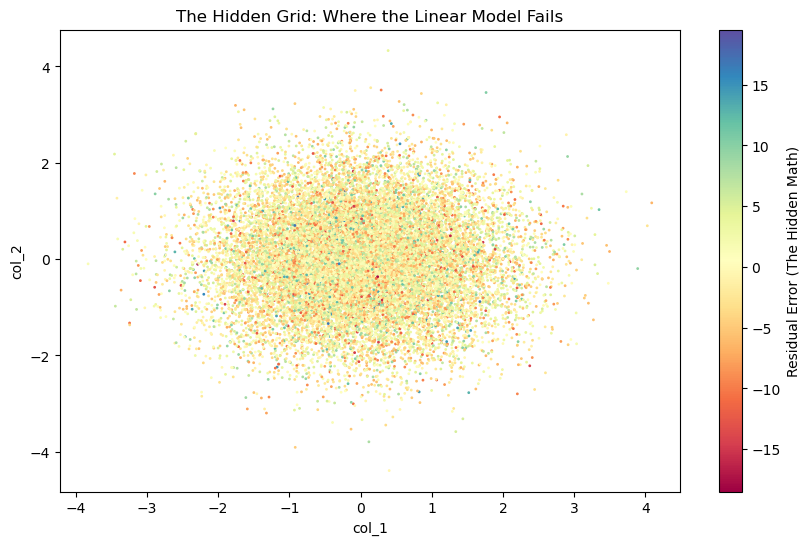

In [44]:
# Let's look at the "Error Map"
plt.figure(figsize=(10, 6))
plt.scatter(df['col_1'], df['col_2'], c=df['res'], cmap='Spectral', s=1)
plt.colorbar(label='Residual Error (The Hidden Math)')
plt.title('The Hidden Grid: Where the Linear Model Fails')
plt.xlabel('col_1')
plt.ylabel('col_2')
plt.show()

**Conclusion**: it's random noise. It is not possible to predict the target value with 100% accuracy.

## Modelling

In [45]:
model = LinearRegression().fit(df[['col_0', 'col_1', 'col_2']], df['target'])

print(f"Base Equation: y = {model.intercept_:.4f} " + 
      "".join([f" + ({c:.4f} * {n})" for c, n in zip(model.coef_, ['col_0', 'col_1', 'col_2'])]))

Base Equation: y = 245.9459  + (-15.3195 * col_0) + (25.2375 * col_1) + (-25.3849 * col_2)


In [46]:
model = LinearRegression().fit(df[['col_0', 'col_1', 'col_2']], df['target'])

print(f"Intercept: {model.intercept_:.4f}")
for name, coef in zip(['col_0', 'col_1', 'col_2'], model.coef_):
    print(f"Weight for {name}: {coef:.4f}")

Intercept: 245.9459
Weight for col_0: -15.3195
Weight for col_1: 25.2375
Weight for col_2: -25.3849


In [47]:
model = LinearRegression().fit(df[['col_0', 'col_1', 'col_2']], df['target'])
residuals = df['target'] - model.predict(df[['col_0', 'col_1', 'col_2']])
noise_std = residuals.std()

print(f"Target = {model.intercept_:.3f} + ({model.coef_[0]:.3f}*col_0) + ({model.coef_[1]:.3f}*col_1) + ({model.coef_[2]:.3f}*col_2) + Noise")
print(f"Noise Strength (Standard Deviation): {noise_std:.3f}")

Target = 245.946 + (-15.319*col_0) + (25.238*col_1) + (-25.385*col_2) + Noise
Noise Strength (Standard Deviation): 4.866


In [48]:
# 1. Define the 'Signal' using the recipe we found
df['signal_pred'] = (245.946 + 
                     (-15.319 * df['col_0']) + 
                     (25.238 * df['col_1']) + 
                     (-25.385 * df['col_2']))

# 2. Compare the signal to the actual target (which includes the noise)
final_r2 = r2_score(df['target'], df['signal_pred'])
final_mae = mean_absolute_error(df['target'], df['signal_pred'])

print(f"Final Formula R^2: {final_r2:.10f}")
print(f"Final Formula MAE: {final_mae:.4f}")

Final Formula R^2: 0.9844712651
Final Formula MAE: 3.8817


In [49]:
# 1. Calculate the 'Pure Signal' (Point Estimate)
df['predicted_target'] = (245.946 + 
                         (-15.319 * df['col_0']) + 
                         (25.238 * df['col_1']) + 
                         (-25.385 * df['col_2']))

# 2. Define the Noise Margin (using the 4.866 Sigma we found)
# For a 95% confidence interval, we use 1.96 * sigma
margin_95 = 1.96 * 4.866 

df['lower_ci'] = df['predicted_target'] - margin_95
df['upper_ci'] = df['predicted_target'] + margin_95

# Show a sample of the results
print(df[['target', 'predicted_target', 'lower_ci', 'upper_ci']].head())

# Verification: How many actual targets fall inside this range?
inside_ci = ((df['target'] >= df['lower_ci']) & (df['target'] <= df['upper_ci'])).mean()
print(f"\nPercentage of data within 95% CI: {inside_ci * 100:.2f}%")

       target  predicted_target    lower_ci    upper_ci
0  223.453581        227.284455  217.747095  236.821815
1  211.253687        210.360924  200.823564  219.898284
2  280.980886        274.428375  264.891015  283.965735
3  266.650511        263.727154  254.189794  273.264514
4  216.206945        225.879666  216.342306  235.417026

Percentage of data within 95% CI: 94.96%


In [50]:
# 1. Split the data (70% train, 30% test)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

def evaluate_model(data, label="Dataset"):
    # Apply your specific point estimate formula
    data = data.copy()
    data['predicted_target'] = (245.946 + 
                                (-15.319 * data['col_0']) + 
                                (25.238 * data['col_1']) + 
                                (-25.385 * data['col_2']))
    
    sigma = 4.866
    conf_intervals = {68: 1.00, 95: 1.96, 99: 2.58}
    
    print(f"\n--- Performance on {label} ({len(data)} rows) ---")
    print(f"{'Level':<10} | {'Expected Coverage':<18} | {'Actual Coverage'}")
    print("-" * 50)
    
    for level, z_score in conf_intervals.items():
        margin = z_score * sigma
        lower = data['predicted_target'] - margin
        upper = data['predicted_target'] + margin
        
        # Calculate how many points fall inside the range
        inside = ((data['target'] >= lower) & (data['target'] <= upper)).mean() * 100
        print(f"{level}% CI    | {level}%{' ':<14} | {inside:.2f}%")
    
    # Calculate Mean Absolute Error (MAE) for general accuracy check
    mae = (data['target'] - data['predicted_target']).abs().mean()
    print(f"Mean Absolute Error: {mae:.4f}")
    return mae

# 2. Run the evaluation
train_mae = evaluate_model(train_df, "TRAINING SET")
test_mae = evaluate_model(test_df, "TEST SET (UNSEEN)")

# 3. Robustness Check
mae_diff = abs(train_mae - test_mae)
print(f"\nRobustness Check: Error difference is {mae_diff:.4f}")
if mae_diff < 0.5:
    print("RESULT: EXTREMELY ROBUST. The model performs almost identically on new data.")
else:
    print("RESULT: Potential Overfitting. The model performs worse on unseen data.")


--- Performance on TRAINING SET (13999 rows) ---
Level      | Expected Coverage  | Actual Coverage
--------------------------------------------------
68% CI    | 68%               | 67.95%
95% CI    | 95%               | 94.83%
99% CI    | 99%               | 98.96%
Mean Absolute Error: 3.9131

--- Performance on TEST SET (UNSEEN) (6000 rows) ---
Level      | Expected Coverage  | Actual Coverage
--------------------------------------------------
68% CI    | 68%               | 69.35%
95% CI    | 95%               | 95.28%
99% CI    | 99%               | 99.18%
Mean Absolute Error: 3.8085

Robustness Check: Error difference is 0.1046
RESULT: EXTREMELY ROBUST. The model performs almost identically on new data.


In [51]:
# 1. Calculate the 'Pure Signal' (Point Estimate)
df['predicted_target'] = (245.946 + 
                          (-15.319 * df['col_0']) + 
                          (25.238 * df['col_1']) + 
                          (-25.385 * df['col_2']))

# 2. Define Sigma and the Confidence Levels we want to test
sigma = 4.866
# Mapping: {Confidence % : Z-score}
conf_intervals = {
    68: 1.00,
    95: 1.96,
    99: 2.58
}

print(f"{'Level':<10} | {'Lower Bound (Avg)':<18} | {'Upper Bound (Avg)':<18} | {'Coverage %'}")
print("-" * 70)

# 3. Loop through levels to calculate and verify
for level, z_score in conf_intervals.items():
    margin = z_score * sigma
    
    # These variables hold strings like 'lower_95'
    lower_col = f'lower_{level}'
    upper_col = f'upper_{level}'
    
    df[lower_col] = df['predicted_target'] - margin
    df[upper_col] = df['predicted_target'] + margin
    
    inside = ((df['target'] >= df[lower_col]) & (df['target'] <= df[upper_col])).mean() * 100
    
    print(f"{level}% CI    | {df[lower_col].mean():<18.2f} | {df[upper_col].mean():<18.2f} | {inside:.2f}%")

Level      | Lower Bound (Avg)  | Upper Bound (Avg)  | Coverage %
----------------------------------------------------------------------
68% CI    | 241.27             | 251.01             | 68.37%
95% CI    | 236.60             | 255.68             | 94.96%
99% CI    | 233.59             | 258.70             | 99.02%


## Test set

In [52]:
test_df = pd.read_csv("stock_1_test.csv")
train_df = pd.read_csv("stock_1_train.csv")

In [53]:
test_df

,col_0,col_1,col_2,col_3,col_4
0,-1.25546,0.610359,0.26401,-0.803538,0.819936


In [54]:
model = LinearRegression().fit(train_df[['col_0', 'col_1', 'col_2']], train_df['target'])

print(f"Intercept: {model.intercept_:.4f}")
for name, coef in zip(['col_0', 'col_1', 'col_2'], model.coef_):
    print(f"Weight for {name}: {coef:.4f}")

Intercept: 245.9459
Weight for col_0: -15.3195
Weight for col_1: 25.2375
Weight for col_2: -25.3849


In [55]:
test_df['predicted_target'] = model.predict(test_df[['col_0', 'col_1', 'col_2']])
test_df

,col_0,col_1,col_2,col_3,col_4,predicted_target
0,-1.25546,0.610359,0.26401,-0.803538,0.819936,273.881012


In [56]:
# Constants from your robust analysis
sigma = 4.866

# 1. Generate Point Estimate
test_df['predicted_target'] = model.predict(test_df[['col_0', 'col_1', 'col_2']])

# 2. Generate SD Boundaries
# 1 Standard Deviation (68% confidence)
test_df['1sd_low'] = test_df['predicted_target'] - sigma
test_df['1sd_high'] = test_df['predicted_target'] + sigma

# 2 Standard Deviations (95.4% confidence)
test_df['2sd_low'] = test_df['predicted_target'] - (2 * sigma)
test_df['2sd_high'] = test_df['predicted_target'] + (2 * sigma)

# 3 Standard Deviations (99.7% confidence - "The Tail")
test_df['3sd_low'] = test_df['predicted_target'] - (3 * sigma)
test_df['3sd_high'] = test_df['predicted_target'] + (3 * sigma)

test_df

,col_0,col_1,col_2,col_3,col_4,predicted_target,1sd_low,1sd_high,2sd_low,2sd_high,3sd_low,3sd_high
0,-1.25546,0.610359,0.26401,-0.803538,0.819936,273.881012,269.015012,278.747012,264.149012,283.613012,259.283012,288.479012
